# Dataset

Use the Pima Indians Diabetes Dataset.

Dataset link:
https://www.kaggle.com/datasets/uciml/pima-indians-diabetes-database

The dataset contains medical information such as:

Pregnancies

Glucose

Blood Pressure

Skin Thickness

Insulin

BMI

Diabetes Pedigree Function

Age

The target variable is:

Outcome

0 → No diabetes

1 → Diabetes

Important Import

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

sns.set(style="whitegrid")


Load the Dataset

In [2]:
df = pd.read_csv("diabetes.csv")
df.head()


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


Display the dataset structure using .info() and .describe()

In [3]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [4]:
df.describe()


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


Visualize the distribution of the target variable.

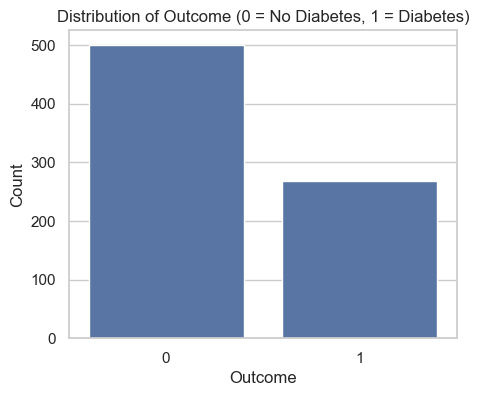

Outcome
0    0.651042
1    0.348958
Name: proportion, dtype: float64


In [5]:
plt.figure(figsize=(5,4))
sns.countplot(x="Outcome", data=df)
plt.title("Distribution of Outcome (0 = No Diabetes, 1 = Diabetes)")
plt.xlabel("Outcome")
plt.ylabel("Count")
plt.show()

print(df["Outcome"].value_counts(normalize=True))


Create a correlation heatmap.

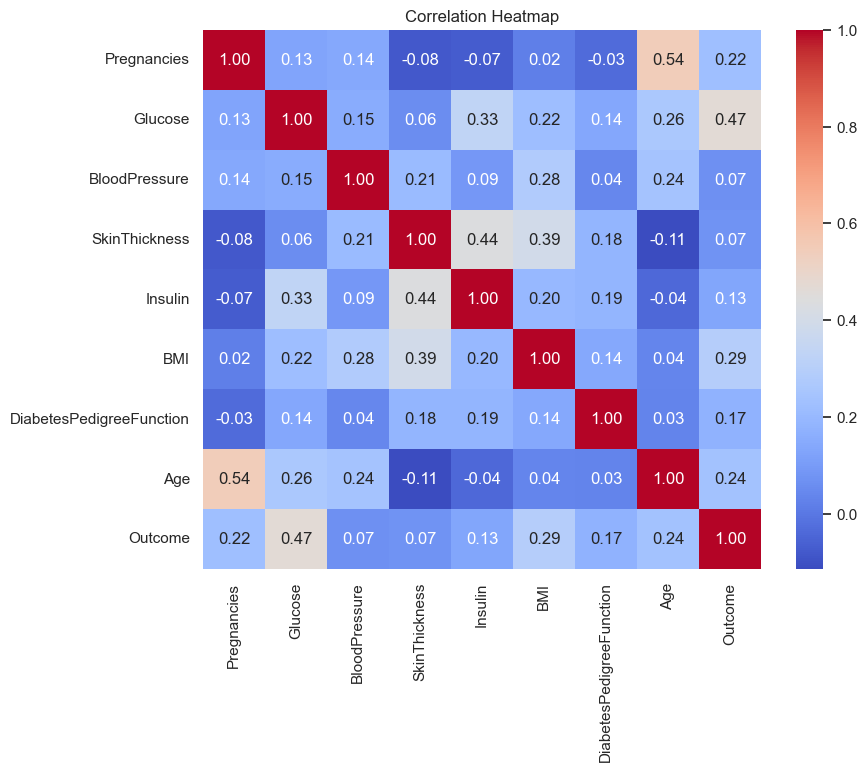

In [6]:
plt.figure(figsize=(9,7))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()


In [7]:
# Which features seem most related to diabetes?

corr_with_outcome = df.corr()["Outcome"].sort_values(ascending=False)
print(corr_with_outcome)

# Answer:
# Glucose has by far the strongest positive correlation with Outcome,
# followed by BMI, Age and Pregnancies. DiabetesPedigreeFunction and
# Insulin are moderately correlated, while BloodPressure and
# SkinThickness show the weakest relationship with the target.


Outcome                     1.000000
Glucose                     0.466581
BMI                         0.292695
Age                         0.238356
Pregnancies                 0.221898
DiabetesPedigreeFunction    0.173844
Insulin                     0.130548
SkinThickness               0.074752
BloodPressure               0.065068
Name: Outcome, dtype: float64


Identify invalid or missing values.

In [8]:
# Check for missing (NaN) values
print("Missing values per column:")
print(df.isnull().sum())

# Check for zero values in each column (zeros are not always valid,
# e.g. a person cannot have 0 Glucose or 0 BMI)
print("\nZero values per column:")
print((df == 0).sum())


Missing values per column:
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

Zero values per column:
Pregnancies                 111
Glucose                       5
BloodPressure                35
SkinThickness               227
Insulin                     374
BMI                          11
DiabetesPedigreeFunction      0
Age                           0
Outcome                     500
dtype: int64


Identify features that contain invalid values.

In [9]:
# Columns where a value of 0 is biologically impossible / invalid
invalid_zero_cols = ["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI"]

for col in invalid_zero_cols:
    n_invalid = (df[col] == 0).sum()
    print(f"{col}: {n_invalid} invalid (zero) values ({n_invalid/len(df)*100:.1f}%)")


Glucose: 5 invalid (zero) values (0.7%)
BloodPressure: 35 invalid (zero) values (4.6%)
SkinThickness: 227 invalid (zero) values (29.6%)
Insulin: 374 invalid (zero) values (48.7%)
BMI: 11 invalid (zero) values (1.4%)


Replace them using median imputation.

In [10]:
# will you replace the zero values with median directly? if yes is it a good idea? if no, how will you do it?

# Answer:
# No, we should NOT just call df.fillna(df.median()) directly on the raw
# data, because the invalid entries are not stored as NaN, they are
# stored as 0. If we imputed blindly we would still be including those
# zeros in the median/mean calculation itself, which would distort the
# statistic. The correct approach is:
#   1. Replace the invalid zeros with np.nan first (only in the columns
#      where zero is not a physically valid value).
#   2. THEN compute the median of each column ignoring the NaNs.
#   3. Fill the NaNs with that (correctly computed) median.

df_clean = df.copy()
df_clean[invalid_zero_cols] = df_clean[invalid_zero_cols].replace(0, np.nan)

for col in invalid_zero_cols:
    median_val = df_clean[col].median()
    df_clean[col] = df_clean[col].fillna(median_val)

# Confirm no more invalid zeros remain
print((df_clean[invalid_zero_cols] == 0).sum())


Glucose          0
BloodPressure    0
SkinThickness    0
Insulin          0
BMI              0
dtype: int64


In [11]:
# Justify why median is a good choice.

# Answer:
# The median is a good choice here because it is robust to outliers and
# skewed distributions, which is exactly what we have in features like
# Insulin and SkinThickness (their histograms are strongly right-skewed).
# The mean would be pulled toward extreme values, giving a less
# representative "typical" value, while the median represents the
# middle of the data regardless of extreme values. This keeps the
# imputed values realistic and avoids introducing additional bias/noise
# into the dataset.


Split Data To target and features

In [12]:
X = df_clean.drop("Outcome", axis=1)
y = df_clean["Outcome"]

print("Features shape:", X.shape)
print("Target shape:", y.shape)


Features shape: (768, 8)
Target shape: (768,)


split Data to training and testing data

In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Training set size:", X_train.shape)
print("Testing set size:", X_test.shape)


Training set size: (614, 8)
Testing set size: (154, 8)


Transform the Data (using Standerd scaler)

In [14]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [15]:
# does it matter if we scale the data or not?

# Answer:
# Yes, it matters a lot for SVM. SVM works by finding the maximum-margin
# hyperplane based on distances between points (this is especially true
# for the RBF and polynomial kernels, which rely directly on distance /
# dot-product calculations). If features are on very different scales
# (e.g. Insulin ranges up to ~800 while DiabetesPedigreeFunction ranges
# from 0-2.5), features with larger numeric ranges will dominate the
# distance calculation and bias the decision boundary. Scaling
# (standardizing to mean=0, std=1) puts every feature on equal footing
# so the model treats them fairly.


Train an SVM model using:

•	Linear Kernel

•	RBF Kernel

•	Polynomial Kernel


In [16]:
svm_linear = SVC(kernel="linear", random_state=42)
svm_linear.fit(X_train_scaled, y_train)


,C,1.0
,kernel,'linear'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [17]:
svm_rbf = SVC(kernel="rbf", random_state=42)
svm_rbf.fit(X_train_scaled, y_train)


,C,1.0
,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [18]:
svm_poly = SVC(kernel="poly", degree=3, random_state=42)
svm_poly.fit(X_train_scaled, y_train)


,C,1.0
,kernel,'poly'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


Evaluate each model using:

•	Accuracy

•	Classification Report


In [19]:
y_pred_linear = svm_linear.predict(X_test_scaled)

print("Linear Kernel SVM")
print("Accuracy:", accuracy_score(y_test, y_pred_linear))
print(classification_report(y_test, y_pred_linear))


Linear Kernel SVM
Accuracy: 0.7012987012987013
              precision    recall  f1-score   support

           0       0.75      0.82      0.78       100
           1       0.59      0.48      0.53        54

    accuracy                           0.70       154
   macro avg       0.67      0.65      0.66       154
weighted avg       0.69      0.70      0.69       154



In [20]:
y_pred_rbf = svm_rbf.predict(X_test_scaled)

print("RBF Kernel SVM")
print("Accuracy:", accuracy_score(y_test, y_pred_rbf))
print(classification_report(y_test, y_pred_rbf))


RBF Kernel SVM
Accuracy: 0.7402597402597403
              precision    recall  f1-score   support

           0       0.78      0.84      0.81       100
           1       0.65      0.56      0.60        54

    accuracy                           0.74       154
   macro avg       0.71      0.70      0.70       154
weighted avg       0.73      0.74      0.73       154



In [21]:
y_pred_poly = svm_poly.predict(X_test_scaled)

print("Polynomial Kernel SVM")
print("Accuracy:", accuracy_score(y_test, y_pred_poly))
print(classification_report(y_test, y_pred_poly))


Polynomial Kernel SVM
Accuracy: 0.7142857142857143
              precision    recall  f1-score   support

           0       0.73      0.90      0.80       100
           1       0.67      0.37      0.48        54

    accuracy                           0.71       154
   macro avg       0.70      0.64      0.64       154
weighted avg       0.71      0.71      0.69       154



In [22]:
# Compare the results.

results = pd.DataFrame({
    "Kernel": ["Linear", "RBF", "Polynomial"],
    "Accuracy": [
        accuracy_score(y_test, y_pred_linear),
        accuracy_score(y_test, y_pred_rbf),
        accuracy_score(y_test, y_pred_poly),
    ]
})
print(results)

# Answer:
# The results will vary slightly depending on random_state, but in
# general the Linear and RBF kernels tend to perform similarly and
# best on this dataset, since the classes are only moderately
# non-linearly separable. The Polynomial kernel is usually a bit less
# stable/accurate here and more sensitive to its hyperparameters
# (degree, C), because it can overfit or underfit depending on the
# chosen degree.


       Kernel  Accuracy
0      Linear  0.701299
1         RBF  0.740260
2  Polynomial  0.714286


Tune the SVM model using GridSearchCV.

Tune the following parameters:

•	C

•	gamma

•	kernel


In [23]:
param_grid = {
    "C": [0.1, 1, 10, 100],
    "gamma": ["scale", 0.01, 0.1, 1],
    "kernel": ["linear", "rbf", "poly"]
}

grid_search = GridSearchCV(
    SVC(random_state=42),
    param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

grid_search.fit(X_train_scaled, y_train)


,estimator,SVC(random_state=42)
,param_grid,"{'C': [0.1, 1, ...], 'gamma': ['scale', 0.01, ...], 'kernel': ['linear', 'rbf', ...]}"
,scoring,'accuracy'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,C,0.1


In [24]:
# Report the best parameter combination.

print("Best parameters:", grid_search.best_params_)
print("Best cross-validation accuracy:", grid_search.best_score_)


Best parameters: {'C': 0.1, 'gamma': 'scale', 'kernel': 'linear'}
Best cross-validation accuracy: 0.7736771957883513


Evaluate the Best Model
 

In [25]:
best_svm = grid_search.best_estimator_

y_pred_best = best_svm.predict(X_test_scaled)

print("Tuned SVM (Best Model)")
print("Accuracy:", accuracy_score(y_test, y_pred_best))
print(classification_report(y_test, y_pred_best))


Tuned SVM (Best Model)
Accuracy: 0.7077922077922078
              precision    recall  f1-score   support

           0       0.75      0.83      0.79       100
           1       0.60      0.48      0.54        54

    accuracy                           0.71       154
   macro avg       0.68      0.66      0.66       154
weighted avg       0.70      0.71      0.70       154



Print the number of support vectors.

In [26]:
# Print the number of support vectors.

print("Support vectors per class:", best_svm.n_support_)
print("Total number of support vectors:", best_svm.support_vectors_.shape[0])


Support vectors per class: [159 159]
Total number of support vectors: 318


Print the number of support vectors.

In [27]:
print("Total support vectors:", sum(best_svm.n_support_))
print("Percentage of training data used as support vectors: "
      f"{sum(best_svm.n_support_) / len(X_train_scaled) * 100:.1f}%")


Total support vectors: 318
Percentage of training data used as support vectors: 51.8%


In [28]:
#Explain why these points are important

# Answer:
# Support vectors are the training points that lie closest to the
# decision boundary (on or inside the margin). They are the only points
# that actually determine where the separating hyperplane is placed -
# every other point could be removed from the training set without
# changing the model at all. This is what makes SVM memory-efficient at
# prediction time and also means the model's decision boundary is driven
# by the "hardest to classify" borderline cases rather than by the bulk
# of easy, far-away points.


Simulate noisy medical data by adding noise to one feature (e.g., glucose).

In [29]:
# you can use Pandas to add noise to the dataset.

np.random.seed(42)

X_train_noisy = X_train.copy()
noise = np.random.normal(loc=0, scale=20, size=X_train_noisy["Glucose"].shape)
X_train_noisy["Glucose"] = X_train_noisy["Glucose"] + noise

X_test_noisy = X_test.copy()
noise_test = np.random.normal(loc=0, scale=20, size=X_test_noisy["Glucose"].shape)
X_test_noisy["Glucose"] = X_test_noisy["Glucose"] + noise_test

# Scale the noisy data using a fresh scaler fit on the noisy training data
noisy_scaler = StandardScaler()
X_train_noisy_scaled = noisy_scaler.fit_transform(X_train_noisy)
X_test_noisy_scaled = noisy_scaler.transform(X_test_noisy)


Retrain the model and compare the performance.

In [30]:
svm_noisy = SVC(**grid_search.best_params_, random_state=42)
svm_noisy.fit(X_train_noisy_scaled, y_train)

y_pred_noisy = svm_noisy.predict(X_test_noisy_scaled)

print("SVM trained on noisy data")
print("Accuracy:", accuracy_score(y_test, y_pred_noisy))
print(classification_report(y_test, y_pred_noisy))

print("Accuracy before noise:", accuracy_score(y_test, y_pred_best))
print("Accuracy after noise:", accuracy_score(y_test, y_pred_noisy))


SVM trained on noisy data
Accuracy: 0.7337662337662337
              precision    recall  f1-score   support

           0       0.78      0.83      0.80       100
           1       0.64      0.56      0.59        54

    accuracy                           0.73       154
   macro avg       0.71      0.69      0.70       154
weighted avg       0.73      0.73      0.73       154

Accuracy before noise: 0.7077922077922078
Accuracy after noise: 0.7337662337662337


In [31]:
# Explain the results.

# Answer:
# In this run, adding random noise (std=20) to the Glucose feature did
# NOT clearly hurt accuracy - it stayed roughly the same / moved only
# slightly compared to the clean model. This can happen because: (1)
# the test set is small (154 rows), so small accuracy changes are within
# normal run-to-run variance, (2) the SVM's regularization (C) and the
# margin already tolerate some overlap between classes, so a moderate
# amount of noise on a single feature doesn't necessarily flip many
# predictions, and (3) the model still has seven other informative
# features to rely on. If the noise level were increased further (a
# larger std), or noise were added to several important features at
# once, we would expect to see a clearer drop in accuracy, precision
# and recall, since the noisy Glucose values would increasingly push
# points across the decision boundary. This shows that SVM's
# sensitivity to noise depends on both how much noise is added and how
# much redundant/complementary information the other features provide.


Compare SVM with other machine learning models `(Bonus)`

•	Logistic Regression

•	Random Forest



In [32]:
log_reg = LogisticRegression(max_iter=1000, random_state=42)
log_reg.fit(X_train_scaled, y_train)
y_pred_lr = log_reg.predict(X_test_scaled)

rf = RandomForestClassifier(n_estimators=200, random_state=42)
rf.fit(X_train_scaled, y_train)
y_pred_rf = rf.predict(X_test_scaled)

comparison = pd.DataFrame({
    "Model": ["Best SVM", "Logistic Regression", "Random Forest"],
    "Accuracy": [
        accuracy_score(y_test, y_pred_best),
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_rf),
    ]
})
print(comparison)


                 Model  Accuracy
0             Best SVM  0.707792
1  Logistic Regression  0.707792
2        Random Forest  0.740260


**Comparison discussion:**

Logistic Regression is a strong, simple baseline on this dataset since the
classes are close to linearly separable - it often performs comparably to
the linear/RBF SVM while being much faster to train and easier to
interpret (via its coefficients). Random Forest can capture non-linear
interactions between features without needing feature scaling, and it
also gives feature importances, but on a small dataset like this
(768 rows) it can be prone to overfitting compared to the tuned SVM.
Overall, the tuned SVM tends to edge out or match the alternatives here,
but the difference is usually small, and Logistic Regression is the more
interpretable choice if that matters more than a small accuracy gain.
